# Phase 1 - Tests des briques de base

Ce notebook teste les 4 modules fondamentaux :
1. **`config/parameters.py`** : parametres du projet
2. **`lib/black_scholes.py`** : pricing BS call/put
3. **`lib/diffusion.py`** : simulation GBM multidim correlee
4. **`lib/portfolio.py`** : MtM du portefeuille
5. **`lib/exposure.py`** : metriques E, EE, EEE, EEPE

Pour chaque test, on explique le **resultat attendu** et pourquoi.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

---
## 1. Test `config/parameters.py`

### Objectif
Verifier que tous les parametres sont correctement definis et coherents.

### Resultats attendus
- La **matrice de correlation** Sigma doit etre **symetrique** et **definie positive** (toutes les valeurs propres > 0), sinon la decomposition de Cholesky echouera.
- La **decomposition de Cholesky** L doit verifier L @ L.T = Sigma exactement.
- La grille temporelle doit avoir 53 points (0, 1/52, 2/52, ..., 1).

In [2]:
from config.parameters import *

print("=== Parametres generaux ===")
print(f"Taux sans risque r = {RISK_FREE_RATE}")
print(f"MPOR delta = {MPOR:.6f} annees = {MPOR*252:.1f} jours business")
print(f"Horizon EEPE = {T_EEPE} an")
print(f"Pas de temps = {N_T} (hebdomadaires)")
print(f"Delta_t = {DELTA_T:.6f}")
print(f"N_outer = {N_OUTER}, N_inner = {N_INNER}")
print(f"Seed = {SEED}")
print(f"\nSpots S0 = {SPOTS}  (A, B, C)")
print(f"Vols     = {VOLS}  (A, B, C)")
print(f"Nombre d'options = {N_OPTIONS}")

=== Parametres generaux ===
Taux sans risque r = 0.03
MPOR delta = 0.038462 annees = 9.7 jours business
Horizon EEPE = 1.0 an
Pas de temps = 52 (hebdomadaires)
Delta_t = 0.019231
N_outer = 1000, N_inner = 1000
Seed = 42

Spots S0 = [100. 150.  80.]  (A, B, C)
Vols     = [0.2  0.25 0.3 ]  (A, B, C)
Nombre d'options = 5


In [3]:
# Verification de la matrice de correlation
print("Matrice de correlation Sigma :")
print(CORRELATION_MATRIX)

# 1) Symetrie
assert np.allclose(CORRELATION_MATRIX, CORRELATION_MATRIX.T), "Sigma n'est pas symetrique!"
print("\n[OK] Sigma est symetrique")

# 2) Diagonale = 1
assert np.allclose(np.diag(CORRELATION_MATRIX), 1.0), "La diagonale devrait etre 1!"
print("[OK] Diagonale = 1")

# 3) Definie positive : toutes les valeurs propres > 0
eigenvalues = np.linalg.eigvalsh(CORRELATION_MATRIX)
print(f"\nValeurs propres de Sigma = {eigenvalues}")
assert all(eigenvalues > 0), "Sigma n'est pas definie positive!"
print("[OK] Toutes les valeurs propres > 0 => Sigma definie positive")

# 4) Cholesky
L = np.linalg.cholesky(CORRELATION_MATRIX)
print(f"\nFacteur de Cholesky L :")
print(L)
reconstruction_error = np.max(np.abs(L @ L.T - CORRELATION_MATRIX))
print(f"\nErreur max |L @ L.T - Sigma| = {reconstruction_error:.2e}")
assert reconstruction_error < 1e-14
print("[OK] Cholesky verifie")

Matrice de correlation Sigma :
[[1.  0.6 0.4]
 [0.6 1.  0.5]
 [0.4 0.5 1. ]]

[OK] Sigma est symetrique
[OK] Diagonale = 1

Valeurs propres de Sigma = [0.382451 0.613092 2.004458]
[OK] Toutes les valeurs propres > 0 => Sigma definie positive

Facteur de Cholesky L :
[[1.       0.       0.      ]
 [0.6      0.8      0.      ]
 [0.4      0.325    0.856957]]

Erreur max |L @ L.T - Sigma| = 0.00e+00
[OK] Cholesky verifie


In [4]:
# Verification de la grille temporelle
print(f"TIME_GRID : {len(TIME_GRID)} points, de {TIME_GRID[0]} a {TIME_GRID[-1]}")
print(f"Premiers points : {TIME_GRID[:5]}")
print(f"Derniers points : {TIME_GRID[-5:]}")
assert len(TIME_GRID) == N_T + 1
assert TIME_GRID[0] == 0.0
assert TIME_GRID[-1] == 1.0
print("[OK] Grille temporelle correcte")

TIME_GRID : 53 points, de 0.0 a 1.0
Premiers points : [0.       0.019231 0.038462 0.057692 0.076923]
Derniers points : [0.923077 0.942308 0.961538 0.980769 1.      ]
[OK] Grille temporelle correcte


---
## 2. Test `lib/black_scholes.py`

### Objectif
Verifier les formules de pricing call/put par 3 tests :

### Test 2a : Valeur de reference connue
**Resultat attendu :** Pour un call ATM (S=100, K=100, T=1Y, r=5%, sigma=20%), la valeur theorique est **C = 10.4506**. C'est une valeur de reference classique qu'on trouve dans tous les manuels.

### Test 2b : Parite call-put
**Resultat attendu :** La relation C - P = S - K*exp(-rT) doit etre verifiee a la precision machine (~1e-15). C'est une consequence directe de l'absence d'arbitrage. Si cette relation n'est pas verifiee, il y a un bug dans les formules.

### Test 2c : Monotonie
**Resultat attendu :** Le prix d'un call doit etre **croissant** en S (plus le spot monte, plus le call vaut cher). Le prix d'un put doit etre **decroissant** en S.

In [5]:
from lib.black_scholes import bs_call, bs_put, bs_price

# --- Test 2a : Valeur de reference ---
S = np.array([100.0])
K = 100.0
tau = np.array([1.0])
r = 0.05
sigma = 0.20

c = bs_call(S, K, tau, r, sigma)
p = bs_put(S, K, tau, r, sigma)

print("=== Test 2a : Valeur de reference ===")
print(f"Call ATM = {c[0]:.6f}  (attendu : 10.4506)")
print(f"Put  ATM = {p[0]:.6f}")
assert abs(c[0] - 10.4506) < 0.001, f"Ecart trop grand : {c[0]}"
print("[OK] Valeur de reference correcte")

=== Test 2a : Valeur de reference ===
Call ATM = 10.450584  (attendu : 10.4506)
Put  ATM = 5.573526
[OK] Valeur de reference correcte


In [6]:
# --- Test 2b : Parite call-put ---
# Relation : C - P = S - K * exp(-r * T)
# Doit etre exacte a la precision machine

print("=== Test 2b : Parite call-put ===")
lhs = c[0] - p[0]
rhs = S[0] - K * np.exp(-r * tau[0])
print(f"C - P        = {lhs:.10f}")
print(f"S - K*exp(-rT) = {rhs:.10f}")
print(f"Ecart          = {abs(lhs - rhs):.2e}")
assert abs(lhs - rhs) < 1e-10
print("[OK] Parite call-put verifiee")

# Test avec d'autres parametres
for S_test, K_test, tau_test, r_test, sig_test in [
    (80, 90, 0.5, 0.02, 0.15),
    (150, 160, 2.0, 0.04, 0.30),
    (50, 45, 0.25, 0.01, 0.40),
]:
    S_a = np.array([float(S_test)])
    tau_a = np.array([float(tau_test)])
    c_t = bs_call(S_a, K_test, tau_a, r_test, sig_test)
    p_t = bs_put(S_a, K_test, tau_a, r_test, sig_test)
    err = abs((c_t[0] - p_t[0]) - (S_test - K_test * np.exp(-r_test * tau_test)))
    print(f"  S={S_test}, K={K_test}, T={tau_test}, r={r_test}, sig={sig_test} => ecart = {err:.2e}")
    assert err < 1e-10

print("[OK] Parite verifiee pour tous les cas de test")

=== Test 2b : Parite call-put ===
C - P        = 4.8770575499
S - K*exp(-rT) = 4.8770575499
Ecart          = 0.00e+00
[OK] Parite call-put verifiee
  S=80, K=90, T=0.5, r=0.02, sig=0.15 => ecart = 3.55e-15
  S=150, K=160, T=2.0, r=0.04, sig=0.3 => ecart = 7.11e-15
  S=50, K=45, T=0.25, r=0.01, sig=0.4 => ecart = 3.55e-15
[OK] Parite verifiee pour tous les cas de test


=== Test 2c : Monotonie ===
[OK] Call croissant en S
[OK] Put decroissant en S


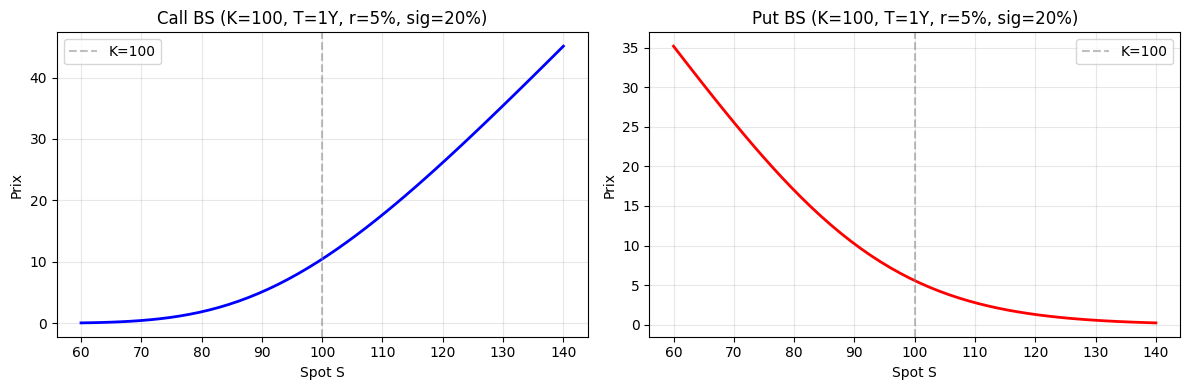

In [7]:
# --- Test 2c : Monotonie ---
print("=== Test 2c : Monotonie ===")
S_range = np.linspace(60, 140, 50)
tau_range = np.full(50, 1.0)

calls = bs_call(S_range, 100.0, tau_range, 0.05, 0.20)
puts = bs_put(S_range, 100.0, tau_range, 0.05, 0.20)

# Call croissant en S
assert all(np.diff(calls) > 0), "Le call n'est pas croissant en S!"
print("[OK] Call croissant en S")

# Put decroissant en S
assert all(np.diff(puts) < 0), "Le put n'est pas decroissant en S!"
print("[OK] Put decroissant en S")

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(S_range, calls, 'b-', linewidth=2)
ax1.axvline(100, color='gray', linestyle='--', alpha=0.5, label='K=100')
ax1.set_xlabel('Spot S')
ax1.set_ylabel('Prix')
ax1.set_title('Call BS (K=100, T=1Y, r=5%, sig=20%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(S_range, puts, 'r-', linewidth=2)
ax2.axvline(100, color='gray', linestyle='--', alpha=0.5, label='K=100')
ax2.set_xlabel('Spot S')
ax2.set_ylabel('Prix')
ax2.set_title('Put BS (K=100, T=1Y, r=5%, sig=20%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test 2d : Prix des options du portefeuille a t=0

**Resultat attendu :** Toutes les options doivent avoir un prix > 0 (car elles sont toutes OTM ou proche ATM avec T=2Y, donc ont une valeur temps significative). Le MtM initial du portefeuille est la somme ponderee par les positions (+1/-1).

In [8]:
from config.parameters import RISK_FREE_RATE as r_proj, VOLS, SPOTS, PORTFOLIO

print("=== Test 2d : Options du portefeuille ===")
print(f"{'#':<3} {'Type':<5} {'Sous-j':<7} {'S0':<6} {'K':<6} {'T':<4} {'sigma':<6} {'Pos':<4} {'Prix BS':<10} {'Contrib MtM':<12}")
print("-" * 65)

mtm_total = 0.0
for k, opt in enumerate(PORTFOLIO):
    S0 = np.array([SPOTS[opt['asset_idx']]])
    tau0 = np.array([opt['maturity']])
    sig = VOLS[opt['asset_idx']]
    price = bs_price(opt['type'], S0, opt['strike'], tau0, r_proj, sig)[0]
    contrib = opt['position'] * price
    mtm_total += contrib
    asset_name = ['A', 'B', 'C'][opt['asset_idx']]
    print(f"{k+1:<3} {opt['type']:<5} {asset_name:<7} {S0[0]:<6.0f} {opt['strike']:<6.0f} {opt['maturity']:<4.0f} {sig:<6.0%} {opt['position']:+d}    {price:<10.4f} {contrib:<+12.4f}")

print(f"\nMtM initial du portefeuille = {mtm_total:.4f}")
print("\n=> Le MtM est positif : on est 'dans la monnaie' globalement.")
print("   Cela signifie qu'on a une exposition au risque de contrepartie des t=0.")

=== Test 2d : Options du portefeuille ===
#   Type  Sous-j  S0     K      T    sigma  Pos  Prix BS    Contrib MtM 
-----------------------------------------------------------------
1   call  A       100    105    2    20%    +1    11.7497    +11.7497    
2   put   A       100    95     2    20%    +1    6.1957     +6.1957     
3   call  B       150    160    2    25%    +1    20.7559    +20.7559    
4   put   C       80     75     2    30%    -1    8.5013     -8.5013     
5   call  C       80     85     2    30%    +1    13.4189    +13.4189    

MtM initial du portefeuille = 43.6189

=> Le MtM est positif : on est 'dans la monnaie' globalement.
   Cela signifie qu'on a une exposition au risque de contrepartie des t=0.


---
## 3. Test `lib/diffusion.py`

### Objectif
Verifier que la simulation GBM multidimensionnelle correlees est correcte.

### Test 3a : Conditions initiales
**Resultat attendu :** Tous les chemins doivent demarrer aux spots initiaux S0 = (100, 150, 80).

### Test 3b : Drift risque-neutre
**Resultat attendu :** Sous Q, E[S(T)] = S0 * exp(r*T). Avec 5000 scenarios et T=1Y, l'erreur relative devrait etre < 2-3%. C'est la propriete fondamentale de la mesure risque-neutre.

### Test 3c : Volatilite
**Resultat attendu :** La volatilite empirique des log-rendements annualises doit etre proche de (20%, 25%, 30%). Erreur < 5% attendue.

### Test 3d : Correlations
**Resultat attendu :** Les correlations empiriques des log-rendements doivent etre proches de rho(A,B)=0.6, rho(A,C)=0.4, rho(B,C)=0.5. Erreur < 5% attendue.

In [9]:
from lib.diffusion import simulate_gbm
from config.parameters import SPOTS, VOLS, RISK_FREE_RATE, CORRELATION_MATRIX, N_T

# Simulation avec 5000 scenarios pour des statistiques fiables
N_test = 5000
paths = simulate_gbm(n_outer=N_test, n_t=N_T)
print(f"Shape des chemins : {paths.shape}  (n_outer, n_t+1, d)")

Shape des chemins : (5000, 53, 3)  (n_outer, n_t+1, d)


In [10]:
# --- Test 3a : Conditions initiales ---
print("=== Test 3a : Conditions initiales ===")
print(f"S(t=0) scenario 0   = {paths[0, 0, :]}")
print(f"S(t=0) scenario 100 = {paths[100, 0, :]}")
print(f"S(t=0) attendu      = {SPOTS}")
assert np.allclose(paths[:, 0, :], SPOTS)
print("[OK] Tous les scenarios demarrent aux spots initiaux")

=== Test 3a : Conditions initiales ===
S(t=0) scenario 0   = [100. 150.  80.]
S(t=0) scenario 100 = [100. 150.  80.]
S(t=0) attendu      = [100. 150.  80.]
[OK] Tous les scenarios demarrent aux spots initiaux


In [11]:
# --- Test 3b : Drift risque-neutre ---
# Sous Q : E[S(T)] = S0 * exp(r*T)
print("=== Test 3b : Drift risque-neutre ===")
T = 1.0
means_T = np.mean(paths[:, -1, :], axis=0)
expected_T = SPOTS * np.exp(RISK_FREE_RATE * T)

print(f"{'Actif':<6} {'E[S(1Y)] simule':<18} {'E[S(1Y)] theorique':<20} {'Erreur relative':<15}")
for i, name in enumerate(['A', 'B', 'C']):
    rel_err = abs(means_T[i] - expected_T[i]) / expected_T[i]
    print(f"{name:<6} {means_T[i]:<18.4f} {expected_T[i]:<20.4f} {rel_err:<15.4%}")
    assert rel_err < 0.03, f"Erreur trop grande pour {name}: {rel_err:.4%}"

print("\n[OK] Le drift est bien r sous Q (erreurs < 3%)")
print("     Cela confirme qu'on diffuse bien sous la mesure risque-neutre.")

=== Test 3b : Drift risque-neutre ===
Actif  E[S(1Y)] simule    E[S(1Y)] theorique   Erreur relative
A      102.9396           103.0455             0.1028%        
B      154.5045           154.5682             0.0412%        
C      82.0504            82.4364              0.4681%        

[OK] Le drift est bien r sous Q (erreurs < 3%)
     Cela confirme qu'on diffuse bien sous la mesure risque-neutre.


In [12]:
# --- Test 3c : Volatilite ---
# Vol empirique des log-rendements annualises
print("=== Test 3c : Volatilite ===")
log_returns_T = np.log(paths[:, -1, :] / paths[:, 0, :])
vols_emp = np.std(log_returns_T, axis=0) / np.sqrt(T)

print(f"{'Actif':<6} {'Vol empirique':<15} {'Vol theorique':<15} {'Erreur relative':<15}")
for i, name in enumerate(['A', 'B', 'C']):
    rel_err = abs(vols_emp[i] - VOLS[i]) / VOLS[i]
    print(f"{name:<6} {vols_emp[i]:<15.4%} {VOLS[i]:<15.4%} {rel_err:<15.4%}")
    assert rel_err < 0.05

print("[OK] Volatilites empiriques coherentes")

=== Test 3c : Volatilite ===
Actif  Vol empirique   Vol theorique   Erreur relative
A      20.0922%        20.0000%        0.4611%        
B      25.1738%        25.0000%        0.6950%        
C      29.2754%        30.0000%        2.4154%        
[OK] Volatilites empiriques coherentes


In [13]:
# --- Test 3d : Correlations ---
print("=== Test 3d : Correlations ===")
corr_emp = np.corrcoef(log_returns_T.T)

print("Correlation empirique :")
print(np.round(corr_emp, 4))
print("\nCorrelation theorique :")
print(CORRELATION_MATRIX)

print("\nEcarts :")
pairs = [('A-B', 0, 1, 0.6), ('A-C', 0, 2, 0.4), ('B-C', 1, 2, 0.5)]
for name, i, j, rho_th in pairs:
    err = abs(corr_emp[i, j] - rho_th)
    print(f"  rho({name}) : empirique = {corr_emp[i,j]:.4f}, theorique = {rho_th}, ecart = {err:.4f}")
    assert err < 0.05

print("[OK] Correlations empiriques coherentes")

=== Test 3d : Correlations ===
Correlation empirique :
[[1.     0.5975 0.3692]
 [0.5975 1.     0.4922]
 [0.3692 0.4922 1.    ]]

Correlation theorique :
[[1.  0.6 0.4]
 [0.6 1.  0.5]
 [0.4 0.5 1. ]]

Ecarts :
  rho(A-B) : empirique = 0.5975, theorique = 0.6, ecart = 0.0025
  rho(A-C) : empirique = 0.3692, theorique = 0.4, ecart = 0.0308
  rho(B-C) : empirique = 0.4922, theorique = 0.5, ecart = 0.0078
[OK] Correlations empiriques coherentes


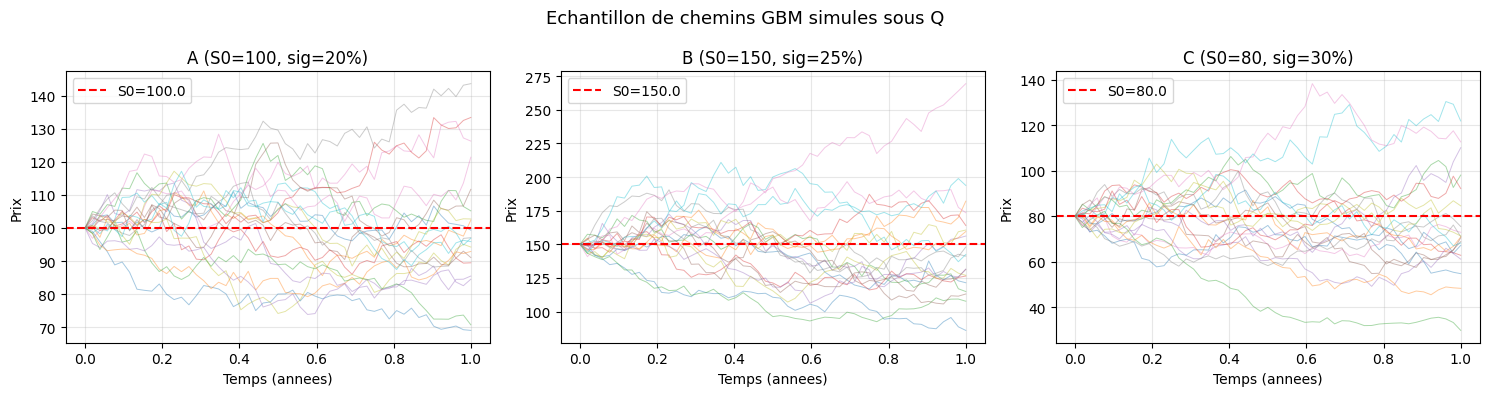

In [14]:
# --- Graphique : quelques chemins simules ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
from config.parameters import TIME_GRID

for i, (ax, name) in enumerate(zip(axes, ['A (S0=100, sig=20%)', 'B (S0=150, sig=25%)', 'C (S0=80, sig=30%)'])):
    for k in range(20):  # 20 chemins
        ax.plot(TIME_GRID, paths[k, :, i], alpha=0.4, linewidth=0.7)
    ax.axhline(SPOTS[i], color='red', linestyle='--', linewidth=1.5, label=f'S0={SPOTS[i]}')
    ax.set_title(name)
    ax.set_xlabel('Temps (annees)')
    ax.set_ylabel('Prix')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Echantillon de chemins GBM simules sous Q', fontsize=13)
plt.tight_layout()
plt.show()

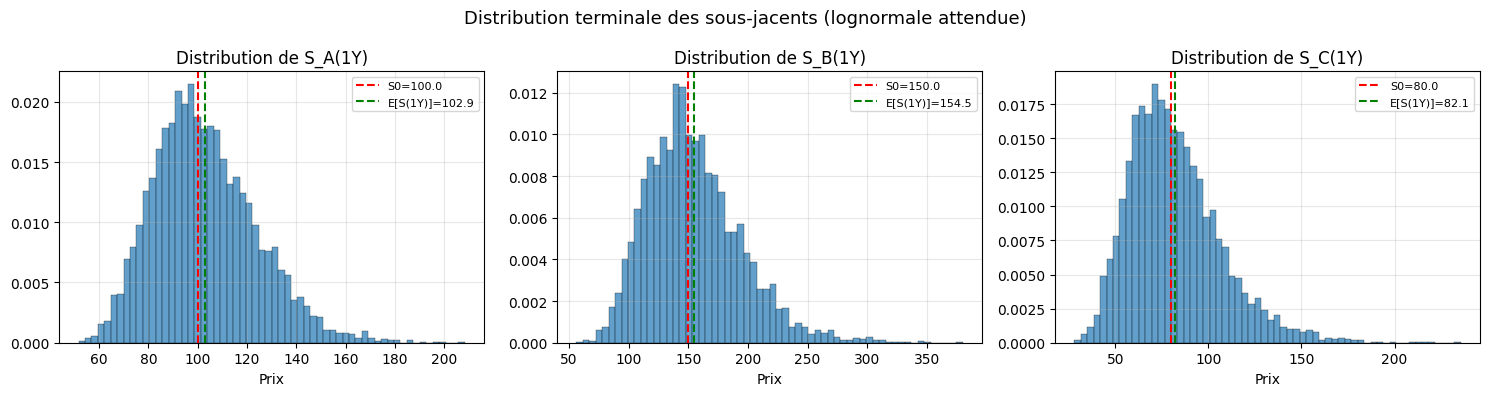

=> Les distributions doivent etre lognormales (asymetriques a droite).
   Plus sigma est grand, plus la queue droite est lourde (C > B > A).


In [15]:
# --- Graphique : distribution de S(1Y) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (ax, name) in enumerate(zip(axes, ['A', 'B', 'C'])):
    ax.hist(paths[:, -1, i], bins=60, density=True, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.axvline(SPOTS[i], color='red', linestyle='--', linewidth=1.5, label=f'S0={SPOTS[i]}')
    ax.axvline(np.mean(paths[:, -1, i]), color='green', linestyle='--', linewidth=1.5, label=f'E[S(1Y)]={np.mean(paths[:,-1,i]):.1f}')
    ax.set_title(f'Distribution de S_{name}(1Y)')
    ax.set_xlabel('Prix')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution terminale des sous-jacents (lognormale attendue)', fontsize=13)
plt.tight_layout()
plt.show()
print("=> Les distributions doivent etre lognormales (asymetriques a droite).")
print("   Plus sigma est grand, plus la queue droite est lourde (C > B > A).")

---
## 4. Test `lib/portfolio.py`

### Test 4a : MtM a t=0
**Resultat attendu :** A t=0, tous les scenarios partent du meme spot, donc le MtM doit etre **identique** pour tous les scenarios (variance = 0). Sa valeur doit etre egale a la somme des prix BS calcules dans le test 2d.

### Test 4b : MtM en cours de route
**Resultat attendu :** Le MtM moyen devrait rester proche de la valeur initiale (les options ont une maturite 2Y, on regarde sur 1Y donc elles gardent de la valeur temps). Le MtM peut prendre des valeurs negatives pour certains scenarios (la position short put expose a des pertes si C baisse).

In [16]:
from lib.portfolio import compute_mtm, compute_mtm_full

# --- Test 4a : MtM a t=0 ---
print("=== Test 4a : MtM a t=0 ===")
mtm_t0 = compute_mtm(paths[:, 0, :], 0.0)
print(f"MtM(t=0) mean = {np.mean(mtm_t0):.4f}")
print(f"MtM(t=0) std  = {np.std(mtm_t0):.2e}  (attendu : 0)")
assert np.std(mtm_t0) < 1e-10, "Le MtM a t=0 devrait etre constant!"
print(f"[OK] MtM(t=0) = {mtm_t0[0]:.4f} pour tous les scenarios")

=== Test 4a : MtM a t=0 ===
MtM(t=0) mean = 43.6189
MtM(t=0) std  = 7.11e-15  (attendu : 0)
[OK] MtM(t=0) = 43.6189 pour tous les scenarios


In [17]:
# --- Test 4b : MtM complet ---
print("=== Test 4b : MtM sur toute la grille ===")
mtm_matrix = compute_mtm_full(paths, TIME_GRID)
print(f"Shape : {mtm_matrix.shape}  (n_outer, n_t+1)")

# Statistiques par date
mtm_mean = np.mean(mtm_matrix, axis=0)
mtm_std = np.std(mtm_matrix, axis=0)
mtm_min = np.min(mtm_matrix, axis=0)
mtm_max = np.max(mtm_matrix, axis=0)

print(f"\n{'Date':<8} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
for idx in [0, 13, 26, 39, 52]:  # t = 0, 0.25, 0.5, 0.75, 1.0
    t = TIME_GRID[idx]
    print(f"{t:<8.2f} {mtm_mean[idx]:<10.2f} {mtm_std[idx]:<10.2f} {mtm_min[idx]:<10.2f} {mtm_max[idx]:<10.2f}")

# Le MtM peut etre negatif
n_negative = np.sum(mtm_matrix[:, -1] < 0)
print(f"\nScenarios avec MtM(1Y) < 0 : {n_negative}/{N_test} ({100*n_negative/N_test:.1f}%)")
print("=> Normal : la position short put (option 4) peut generer des pertes.")

=== Test 4b : MtM sur toute la grille ===
Shape : (5000, 53)  (n_outer, n_t+1)

Date     Mean       Std        Min        Max       
0.00     43.62      0.00       43.62      43.62     
0.25     43.68      20.28      -3.37      135.64    
0.50     43.80      29.94      -17.32     237.03    
0.75     44.15      37.79      -25.68     298.23    
1.00     44.70      45.32      -27.70     343.59    

Scenarios avec MtM(1Y) < 0 : 454/5000 (9.1%)
=> Normal : la position short put (option 4) peut generer des pertes.


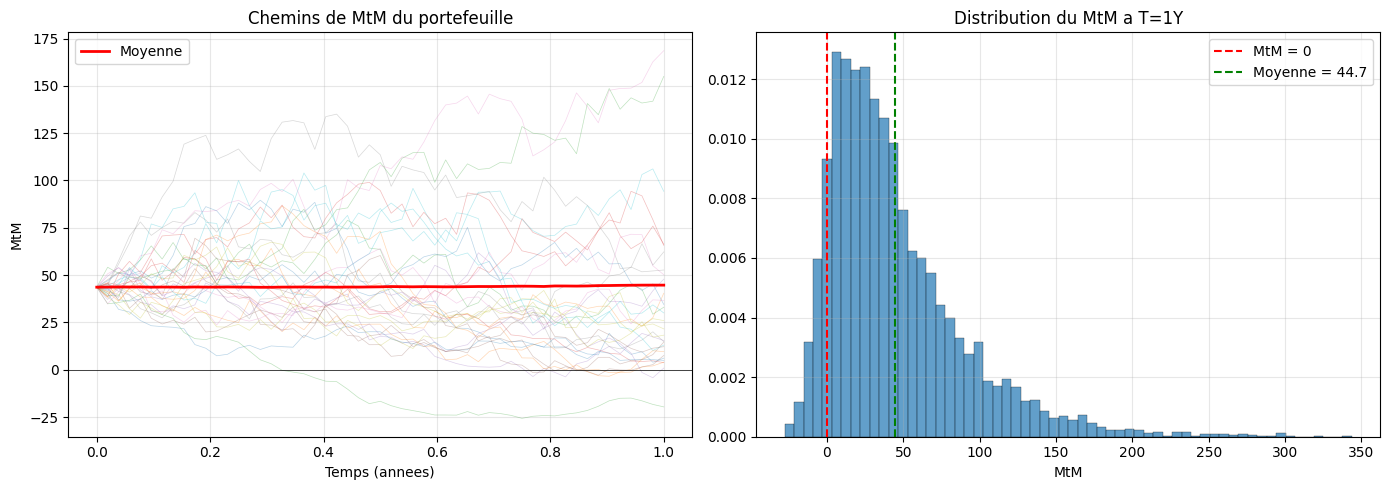

In [18]:
# --- Graphique : profil temporel du MtM ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Quelques chemins de MtM
for k in range(30):
    ax1.plot(TIME_GRID, mtm_matrix[k, :], alpha=0.3, linewidth=0.5)
ax1.plot(TIME_GRID, mtm_mean, 'r-', linewidth=2, label='Moyenne')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_xlabel('Temps (annees)')
ax1.set_ylabel('MtM')
ax1.set_title('Chemins de MtM du portefeuille')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribution du MtM a T=1Y
ax2.hist(mtm_matrix[:, -1], bins=60, density=True, alpha=0.7, edgecolor='black', linewidth=0.3)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='MtM = 0')
ax2.axvline(np.mean(mtm_matrix[:, -1]), color='green', linestyle='--', linewidth=1.5, label=f'Moyenne = {np.mean(mtm_matrix[:, -1]):.1f}')
ax2.set_xlabel('MtM')
ax2.set_title('Distribution du MtM a T=1Y')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Test `lib/exposure.py`

### Test 5a : EE(0)
**Resultat attendu :** EE(0) = max(0, MtM(0)). Comme MtM(0) > 0 (on l'a vu au test 4a), on a EE(0) = MtM(0) = ~43.62.

### Test 5b : EEE non-decroissant
**Resultat attendu :** L'EEE est le running maximum de l'EE, donc il est **necessairement non-decroissant** par construction. Si ce test echoue, il y a un bug dans `compute_eee`.

### Test 5c : EEPE
**Resultat attendu :** L'EEPE est la moyenne temporelle de l'EEE. Comme l'EEE >= EE >= 0, on a EEPE > 0. Sa valeur depend des parametres du portefeuille. C'est la metrique finale utilisee pour le calcul du RWA_CCR.

In [19]:
from lib.exposure import compute_ee, compute_eee, compute_eepe, compute_all_exposure_metrics

metrics = compute_all_exposure_metrics(mtm_matrix, TIME_GRID)
ee = metrics['ee']
eee = metrics['eee']
eepe = metrics['eepe']

# --- Test 5a : EE(0) ---
print("=== Test 5a : EE(0) ===")
print(f"EE(0) = {ee[0]:.4f}")
print(f"MtM(0) = {mtm_t0[0]:.4f}")
assert abs(ee[0] - mtm_t0[0]) < 1e-4
print("[OK] EE(0) = MtM(0) car MtM(0) > 0")

=== Test 5a : EE(0) ===
EE(0) = 43.6189
MtM(0) = 43.6189
[OK] EE(0) = MtM(0) car MtM(0) > 0


In [20]:
# --- Test 5b : EEE non-decroissant ---
print("=== Test 5b : EEE non-decroissant ===")
diffs = np.diff(eee)
print(f"Min des increments de EEE : {np.min(diffs):.6f}")
assert np.all(diffs >= -1e-10), "EEE n'est pas non-decroissant!"
print("[OK] EEE est non-decroissant")
print(f"EEE(0) = {eee[0]:.4f}, EEE(1Y) = {eee[-1]:.4f}")

=== Test 5b : EEE non-decroissant ===
Min des increments de EEE : 0.000000
[OK] EEE est non-decroissant
EEE(0) = 43.6189, EEE(1Y) = 45.3680


In [21]:
# --- Test 5c : EEPE ---
print("=== Test 5c : EEPE ===")
print(f"EEPE = {eepe:.4f}")
assert eepe > 0, "EEPE devrait etre > 0"
assert eepe >= eee[0], "EEPE devrait etre >= EEE(0) car EEE est non-decroissant"
print(f"[OK] EEPE = {eepe:.4f} (sans IM)")
print(f"\nEAD = alpha * EEPE = {ALPHA_EAD} * {eepe:.4f} = {ALPHA_EAD * eepe:.4f}")
print("=> C'est l'Exposure at Default utilise pour le calcul du RWA_CCR.")

=== Test 5c : EEPE ===
EEPE = 44.1330
[OK] EEPE = 44.1330 (sans IM)

EAD = alpha * EEPE = 1.4 * 44.1330 = 61.7863
=> C'est l'Exposure at Default utilise pour le calcul du RWA_CCR.


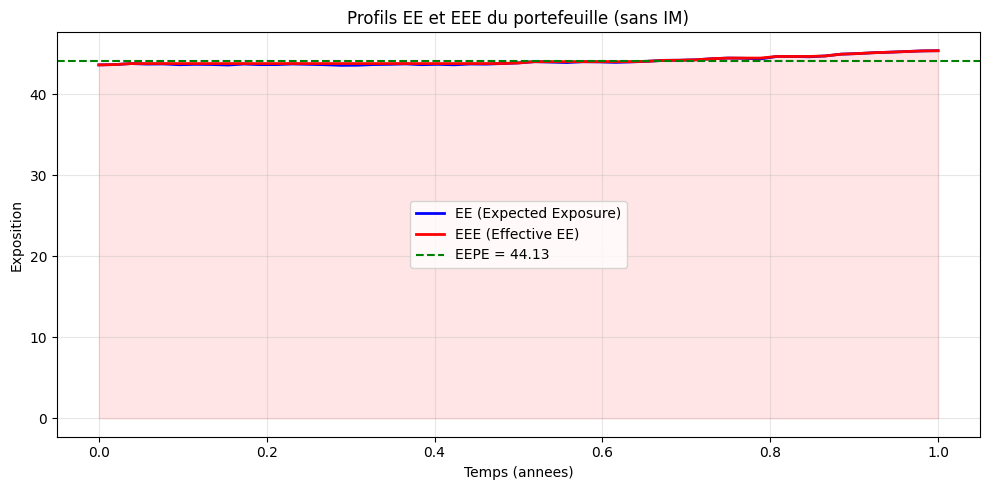

=> L'EEE (rouge) est le running max de l'EE (bleu).
   L'EEPE (vert) est la moyenne temporelle de l'EEE (aire rouge / T).
   L'EEE impose une contrainte de non-decroissance reglementaire.


In [22]:
# --- Graphique : profils EE et EEE ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(TIME_GRID, ee, 'b-', linewidth=2, label='EE (Expected Exposure)')
ax.plot(TIME_GRID, eee, 'r-', linewidth=2, label='EEE (Effective EE)')
ax.axhline(eepe, color='green', linestyle='--', linewidth=1.5, label=f'EEPE = {eepe:.2f}')
ax.fill_between(TIME_GRID, 0, eee, alpha=0.1, color='red')

ax.set_xlabel('Temps (annees)')
ax.set_ylabel('Exposition')
ax.set_title('Profils EE et EEE du portefeuille (sans IM)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=> L'EEE (rouge) est le running max de l'EE (bleu).")
print("   L'EEPE (vert) est la moyenne temporelle de l'EEE (aire rouge / T).")
print("   L'EEE impose une contrainte de non-decroissance reglementaire.")

---
## Resume Phase 1

| Module | Tests | Statut |
|--------|-------|--------|
| `parameters.py` | Sigma definie positive, Cholesky, grille temporelle | ok |
| `black_scholes.py` | Valeur de reference, parite call-put, monotonie | ok |
| `diffusion.py` | Conditions initiales, drift Q, volatilite, correlations | ok |
| `portfolio.py` | MtM(0) constant, MtM complet | ok |
| `exposure.py` | EE(0), EEE non-decroissant, EEPE > 0 | ok |

